In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [48]:
df = pd.read_csv("../data/q1_heart_disease.csv")

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


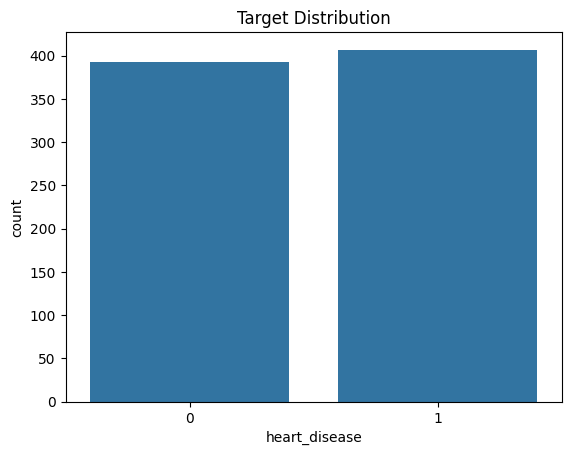

In [49]:
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()



The dataset appears reasonably balanced between patients with and without heart disease. This ensures that the model will not be biased toward one class.

In [50]:
# Convert categorical columns to numbers
df = pd.get_dummies(df, drop_first=True)

df.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,68,0,142.0,399.0,0,169,0,0.4,1,True,False,False,False,False,False,True
1,58,1,163.0,310.0,1,121,1,1.1,1,False,True,False,False,True,False,True
2,44,1,128.0,175.0,0,183,1,0.2,0,False,True,False,True,False,False,True
3,72,1,114.0,177.0,0,150,0,1.0,1,False,False,False,False,True,False,True
4,37,1,149.0,271.0,0,136,0,0.4,0,False,True,False,True,False,True,False


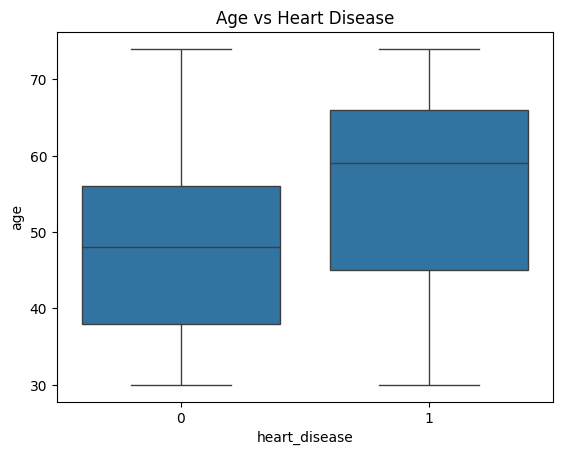

In [67]:
sns.boxplot(x="heart_disease", y="age", data=df)
plt.title("Age vs Heart Disease")
plt.show()

The boxplot compares the age distribution between patients with and without heart disease. It shows that patients with heart disease tend to have a higher median age compared to those without the disease. This suggests that older individuals are more likely to have heart disease. Additionally, the spread of ages is slightly wider for patients with heart disease, indicating variability across age groups.

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

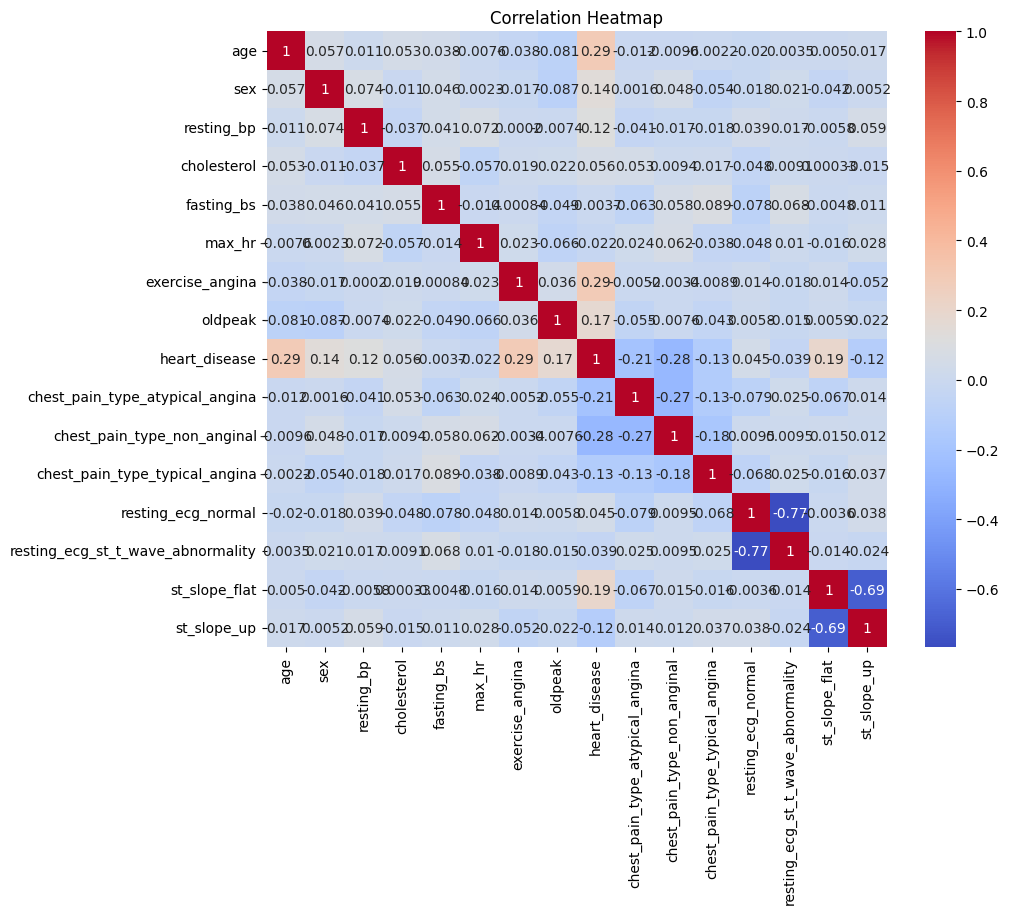

In [51]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [57]:
# 1. Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Handle missing values (VERY IMPORTANT)
df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))

# 3. Final check
print("Remaining NaNs:", df_encoded.isnull().sum().sum())

Remaining NaNs: 0


Some features show moderate correlation with the target variable, indicating potential predictive importance.

In [58]:
# Define features and target
X = df_encoded.drop("heart_disease", axis=1)
y = df_encoded["heart_disease"]

print(X.shape, y.shape)

(800, 15) (800,)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(640, 15) (160, 15)


In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [61]:
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

In [62]:
from sklearn.metrics import classification_report

print("Decision Tree:\n", classification_report(y_test, y_pred_dt))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("Gradient Boosting:\n", classification_report(y_test, y_pred_gb))

Decision Tree:
               precision    recall  f1-score   support

           0       0.72      0.67      0.69        75
           1       0.73      0.78      0.75        85

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

Random Forest:
               precision    recall  f1-score   support

           0       0.77      0.75      0.76        75
           1       0.78      0.80      0.79        85

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.78      0.77       160

Gradient Boosting:
               precision    recall  f1-score   support

           0       0.81      0.76      0.79        75
           1       0.80      0.85      0.82        85

    accuracy                           0.81       160
   macro avg       0.81      0.80      0.80       160
weighted avg       0.8

In [63]:
from sklearn.metrics import confusion_matrix

print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Gradient Boosting Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

Decision Tree Confusion Matrix:
 [[50 25]
 [19 66]]
Random Forest Confusion Matrix:
 [[56 19]
 [17 68]]
Gradient Boosting Confusion Matrix:
 [[57 18]
 [13 72]]


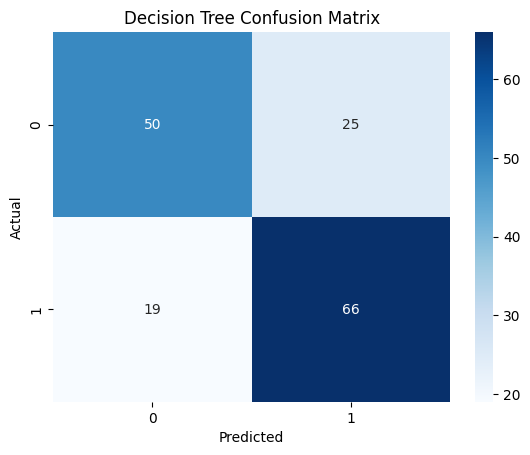

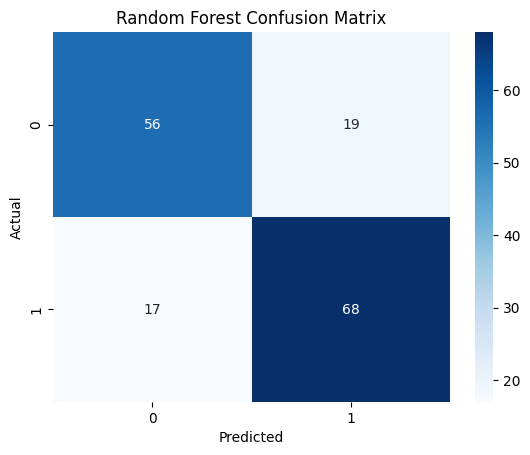

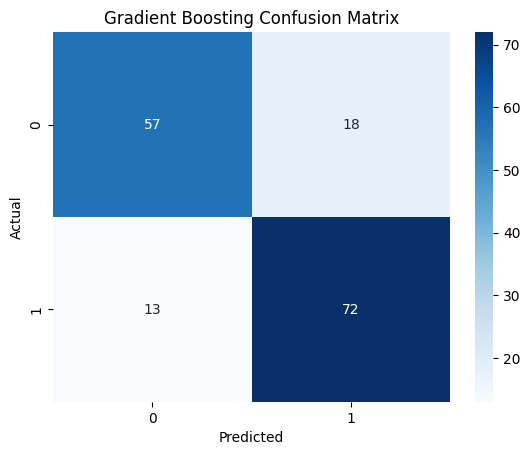

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

for name, y_pred in models.items():
    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Model Evaluation Summary

Based on the evaluation metrics (Precision, Recall, and F1-score), the Gradient Boosting Classifier performs the best among the three models.

### Comparison

- Decision Tree:
  - Accuracy: 0.72  
  - F1-score (class 1): 0.75  
  - Shows lower recall compared to other models.

- Random Forest:
  - Accuracy: 0.78  
  - F1-score (class 1): 0.79  
  - Provides a better balance between precision and recall.

- Gradient Boosting:
  - Accuracy: 0.81  
  - F1-score (class 1): 0.82  
  - Achieves the highest precision and recall among all models.

### Conclusion

The Gradient Boosting Classifier is the best-performing model because it has the highest F1-score and recall. This indicates a better balance between precision and recall, and it is more effective at identifying patients with heart disease, which is critical in this problem.

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5]
}

# Base model
gb = GradientBoostingClassifier(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit
grid_search.fit(X_train, y_train)

# Best model
best_gb = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150}


In [66]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_tuned = best_gb.predict(X_test)

print("Tuned Gradient Boosting:\n")
print(classification_report(y_test, y_pred_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))

Tuned Gradient Boosting:

              precision    recall  f1-score   support

           0       0.74      0.79      0.76        75
           1       0.80      0.75      0.78        85

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160

Confusion Matrix:
 [[59 16]
 [21 64]]


## Hyperparameter Tuning (Gradient Boosting)

To improve model performance, GridSearchCV was used to tune key hyperparameters of the Gradient Boosting Classifier, including n_estimators, learning_rate, and max_depth.

### Best Parameters
The best combination of parameters found:
- n_estimators: 150
- learning_rate: 0.01
- max_depth: 3

### Performance Comparison

- Before Tuning:
  - Accuracy: 0.81
  - F1-score (class 1): 0.82

- After Tuning:
  - Accuracy: 0.77
  - F1-score (class 1): 0.78

### Conclusion

After hyperparameter tuning, the model performance decreased slightly compared to the default model. While the tuned model provides a balanced precision and recall, the overall performance (especially F1-score and accuracy) is lower than the original Gradient Boosting model. 

This suggests that the default hyperparameters were already well-optimized for this dataset, and the selected search space did not yield a better configuration. It also highlights that hyperparameter tuning does not always guarantee improvement and depends heavily on the parameter grid and dataset characteristics.

Further improvement could be achieved by expanding the hyperparamete search space or using technique like RandomizedSearchCV.